In [1]:
##KNN --> Clasificación de Datos

In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df_final = pd.read_csv("../Práctica 1/glp1_limpio.csv", parse_dates=['FECHA'])
df_final['ANIO'] = df_final['FECHA'].dt.year


In [4]:
resumen_consultorio = df_final.groupby('PRACTICE_CODE').agg(
    revenue_total=('ACTUAL_COST', 'sum'),
    items_total=('ITEMS', 'sum'),
    meses_activo=('FECHA', 'nunique'),
    sustancias_distintas=('SUSTANCIA', 'nunique'),
    region=('REGIONAL_OFFICE_NAME', 'first')
).reset_index()

print(resumen_consultorio.shape)
print(resumen_consultorio.head())

(7623, 6)
  PRACTICE_CODE  revenue_total  items_total  meses_activo  \
0        A81001   107090.93676         1351            65   
1        A81002   457833.21482         5360            65   
2        A81004   277479.66767         3005            65   
3        A81005   146283.94816         1599            65   
4        A81006   254177.24869         2560            65   

   sustancias_distintas                    region  
0                     5  NORTH EAST AND YORKSHIRE  
1                     5  NORTH EAST AND YORKSHIRE  
2                     5  NORTH EAST AND YORKSHIRE  
3                     5  NORTH EAST AND YORKSHIRE  
4                     6  NORTH EAST AND YORKSHIRE  


In [5]:
print(resumen_consultorio['revenue_total'].describe())

count    7.623000e+03
mean     2.001956e+05
std      2.063943e+05
min      9.892080e+00
25%      6.213838e+04
50%      1.478436e+05
75%      2.769661e+05
max      2.488317e+06
Name: revenue_total, dtype: float64


In [6]:
mediana_revenue = resumen_consultorio['revenue_total'].median()

resumen_consultorio['ALTO_VALOR'] = (resumen_consultorio['revenue_total'] > mediana_revenue).astype(int)

print(resumen_consultorio['ALTO_VALOR'].value_counts())

ALTO_VALOR
0    3812
1    3811
Name: count, dtype: int64


In [7]:
print(resumen_consultorio[['revenue_total', 'items_total']].corr())

               revenue_total  items_total
revenue_total       1.000000     0.978443
items_total         0.978443     1.000000


In [8]:
print(resumen_consultorio[['revenue_total', 'meses_activo', 'sustancias_distintas']].corr())

                      revenue_total  meses_activo  sustancias_distintas
revenue_total              1.000000      0.435837              0.476595
meses_activo               0.435837      1.000000              0.785138
sustancias_distintas       0.476595      0.785138              1.000000


In [9]:
dummies_region = pd.get_dummies(resumen_consultorio['region'], prefix='REGION')
print(dummies_region.head())

   REGION_EAST OF ENGLAND  REGION_LONDON  REGION_MIDLANDS  \
0                   False          False            False   
1                   False          False            False   
2                   False          False            False   
3                   False          False            False   
4                   False          False            False   

   REGION_NORTH EAST AND YORKSHIRE  REGION_NORTH WEST  REGION_SOUTH EAST  \
0                             True              False              False   
1                             True              False              False   
2                             True              False              False   
3                             True              False              False   
4                             True              False              False   

   REGION_SOUTH WEST  
0              False  
1              False  
2              False  
3              False  
4              False  


In [10]:
resumen_consultorio = pd.concat([resumen_consultorio, dummies_region], axis=1)

columnas_predictoras = ['meses_activo', 'sustancias_distintas'] + list(dummies_region.columns)
X = resumen_consultorio[columnas_predictoras]
y = resumen_consultorio['ALTO_VALOR']

print(X.shape, y.shape)

(7623, 9) (7623,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6098, 9) (1525, 9)


In [12]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train_escalado, y_train)

predicciones = modelo.predict(X_test_escalado)
exactitud = accuracy_score(y_test, predicciones)
print(f'Exactitud con k=5: {exactitud:.3f}')

Exactitud con k=5: 0.705


In [14]:
valores_k = range(1, 21)
exactitudes = []

for k in valores_k:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_escalado, y_train)
    pred_k = modelo_k.predict(X_test_escalado)
    exactitudes.append(accuracy_score(y_test, pred_k))

for k, ex in zip(valores_k, exactitudes):
    print(f'k={k}: exactitud={ex:.3f}')

k=1: exactitud=0.697
k=2: exactitud=0.610
k=3: exactitud=0.683
k=4: exactitud=0.672
k=5: exactitud=0.705
k=6: exactitud=0.690
k=7: exactitud=0.722
k=8: exactitud=0.689
k=9: exactitud=0.744
k=10: exactitud=0.737
k=11: exactitud=0.750
k=12: exactitud=0.751
k=13: exactitud=0.748
k=14: exactitud=0.748
k=15: exactitud=0.739
k=16: exactitud=0.735
k=17: exactitud=0.737
k=18: exactitud=0.744
k=19: exactitud=0.742
k=20: exactitud=0.740


[[531 210]
 [175 609]]


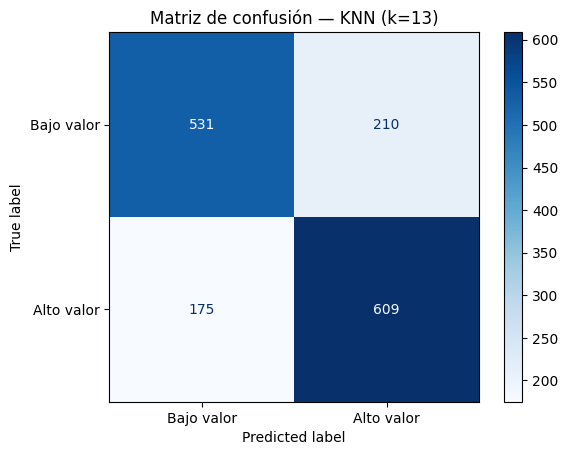

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelo_final = KNeighborsClassifier(n_neighbors=13)
modelo_final.fit(X_train_escalado, y_train)
predicciones_final = modelo_final.predict(X_test_escalado)

matriz = confusion_matrix(y_test, predicciones_final)
print(matriz)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Bajo valor', 'Alto valor'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — KNN (k=13)')
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicciones_final, target_names=['Bajo valor', 'Alto valor']))

              precision    recall  f1-score   support

  Bajo valor       0.75      0.72      0.73       741
  Alto valor       0.74      0.78      0.76       784

    accuracy                           0.75      1525
   macro avg       0.75      0.75      0.75      1525
weighted avg       0.75      0.75      0.75      1525



In [17]:
revenue_temprano = df_final[df_final['FECHA'].dt.year.isin([2021, 2022])].groupby('PRACTICE_CODE')['ACTUAL_COST'].sum()
revenue_tardio = df_final[df_final['FECHA'].dt.year.isin([2024, 2025])].groupby('PRACTICE_CODE')['ACTUAL_COST'].sum()

print(len(revenue_temprano), len(revenue_tardio))

7119 7017


In [18]:
crecimiento_consultorio = pd.DataFrame({
    'revenue_temprano': revenue_temprano,
    'revenue_tardio': revenue_tardio
}).dropna()

crecimiento_consultorio['crecimiento'] = crecimiento_consultorio['revenue_tardio'] - crecimiento_consultorio['revenue_temprano']

print(crecimiento_consultorio.shape)
print(crecimiento_consultorio['crecimiento'].describe())

(6642, 3)
count      6642.000000
mean      42331.445430
std       54717.117795
min     -156333.484800
25%        8861.250945
50%       27601.344960
75%       58945.366430
max      706747.293560
Name: crecimiento, dtype: float64


In [19]:
mediana_crecimiento = crecimiento_consultorio['crecimiento'].median()
crecimiento_consultorio['ALTO_CRECIMIENTO'] = (crecimiento_consultorio['crecimiento'] > mediana_crecimiento).astype(int)

print(crecimiento_consultorio['ALTO_CRECIMIENTO'].value_counts())

ALTO_CRECIMIENTO
0    3321
1    3321
Name: count, dtype: int64


In [20]:
crecimiento_consultorio = crecimiento_consultorio.reset_index().rename(columns={'index': 'PRACTICE_CODE'})

datos_crecimiento = crecimiento_consultorio.merge(
    resumen_consultorio[['PRACTICE_CODE', 'meses_activo', 'sustancias_distintas'] + list(dummies_region.columns)],
    on='PRACTICE_CODE'
)

print(datos_crecimiento.shape)

(6642, 14)


In [21]:
columnas_predictoras_crec = ['meses_activo', 'sustancias_distintas'] + list(dummies_region.columns)
X_crec = datos_crecimiento[columnas_predictoras_crec]
y_crec = datos_crecimiento['ALTO_CRECIMIENTO']

X_train_crec, X_test_crec, y_train_crec, y_test_crec = train_test_split(X_crec, y_crec, test_size=0.2, random_state=42)
print(X_train_crec.shape, X_test_crec.shape)

(5313, 9) (1329, 9)


In [22]:
escalador_crec = StandardScaler()
X_train_crec_escalado = escalador_crec.fit_transform(X_train_crec)
X_test_crec_escalado = escalador_crec.transform(X_test_crec)

In [23]:
exactitudes_crec = []

for k in valores_k:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_crec_escalado, y_train_crec)
    pred_k = modelo_k.predict(X_test_crec_escalado)
    exactitudes_crec.append(accuracy_score(y_test_crec, pred_k))

for k, ex in zip(valores_k, exactitudes_crec):
    print(f'k={k}: exactitud={ex:.3f}')

k=1: exactitud=0.555
k=2: exactitud=0.571
k=3: exactitud=0.561
k=4: exactitud=0.586
k=5: exactitud=0.579
k=6: exactitud=0.573
k=7: exactitud=0.594
k=8: exactitud=0.564
k=9: exactitud=0.615
k=10: exactitud=0.596
k=11: exactitud=0.614
k=12: exactitud=0.611
k=13: exactitud=0.621
k=14: exactitud=0.579
k=15: exactitud=0.610
k=16: exactitud=0.584
k=17: exactitud=0.594
k=18: exactitud=0.595
k=19: exactitud=0.600
k=20: exactitud=0.594


[[434 233]
 [271 391]]


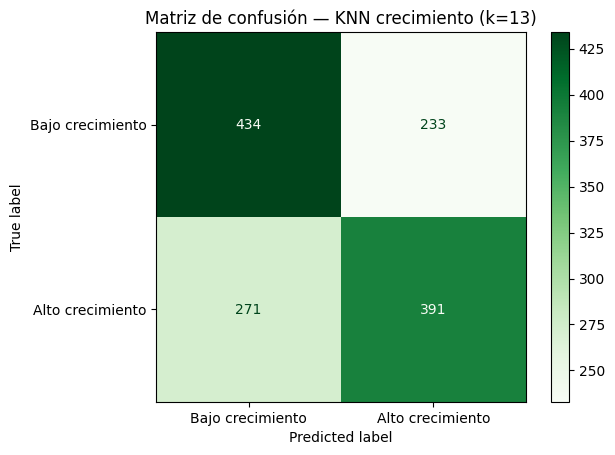

                  precision    recall  f1-score   support

Bajo crecimiento       0.62      0.65      0.63       667
Alto crecimiento       0.63      0.59      0.61       662

        accuracy                           0.62      1329
       macro avg       0.62      0.62      0.62      1329
    weighted avg       0.62      0.62      0.62      1329



In [24]:
modelo_final_crec = KNeighborsClassifier(n_neighbors=13)
modelo_final_crec.fit(X_train_crec_escalado, y_train_crec)
predicciones_final_crec = modelo_final_crec.predict(X_test_crec_escalado)

matriz_crec = confusion_matrix(y_test_crec, predicciones_final_crec)
print(matriz_crec)

disp_crec = ConfusionMatrixDisplay(confusion_matrix=matriz_crec, display_labels=['Bajo crecimiento', 'Alto crecimiento'])
disp_crec.plot(cmap='Greens')
plt.title('Matriz de confusión — KNN crecimiento (k=13)')
plt.show()

print(classification_report(y_test_crec, predicciones_final_crec, target_names=['Bajo crecimiento', 'Alto crecimiento']))

In [25]:
columnas_sin_meses = ['sustancias_distintas'] + list(dummies_region.columns)
columnas_sin_sustancias = ['meses_activo'] + list(dummies_region.columns)

for nombre, columnas in [('Sin meses_activo', columnas_sin_meses), ('Sin sustancias_distintas', columnas_sin_sustancias)]:
    X_var = resumen_consultorio[columnas]
    X_train_var, X_test_var, y_train_var, y_test_var = train_test_split(X_var, y, test_size=0.2, random_state=42)
    
    escalador_var = StandardScaler()
    X_train_var_esc = escalador_var.fit_transform(X_train_var)
    X_test_var_esc = escalador_var.transform(X_test_var)
    
    modelo_var = KNeighborsClassifier(n_neighbors=13)
    modelo_var.fit(X_train_var_esc, y_train_var)
    pred_var = modelo_var.predict(X_test_var_esc)
    
    print(f'{nombre}: exactitud={accuracy_score(y_test_var, pred_var):.3f}')

Sin meses_activo: exactitud=0.721
Sin sustancias_distintas: exactitud=0.702
